In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل البيانات
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# عرض الحجم
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# عرض أول 5 صفوف
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 1. Data Loading
In this step, we imported the required libraries and loaded the training and testing datasets using pandas. We also checked the shape and structure of the data.


In [12]:
cols_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

for col in cols_fill_none:
    if col in train.columns:
        train[col] = train[col].astype(str).fillna("None")
    if col in test.columns:
        test[col] = test[col].astype(str).fillna("None")

 2. Data Inspection
We explored the dataset by checking its dimensions and displaying the first few rows to understand the structure of the features.

In [13]:
train = train[train['GrLivArea'] < 4000]

Removing houses with GrLivArea greater than 4000 square feet as they are extreme outliers that can negatively affect model training

In [15]:
train['SalePrice'] = np.log1p(train['SalePrice'])

Applying a logarithmic transformation (`np.log1p`) to SalePrice to fix its right-skewness and normalize the distribution.

In [16]:
corr = train.corr(numeric_only=True)

top_corr = corr['SalePrice'].sort_values(ascending=False).head(6)
print(top_corr)

SalePrice      1.000000
OverallQual    0.819240
GrLivArea      0.718844
GarageCars     0.680408
GarageArea     0.655212
TotalBsmtSF    0.641553
Name: SalePrice, dtype: float64


3. Exploratory Data Analysis (EDA)
Computing the correlation matrix to identify the top 5 features most strongly correlated with SalePrice.

<function matplotlib.pyplot.show(close=None, block=None)>

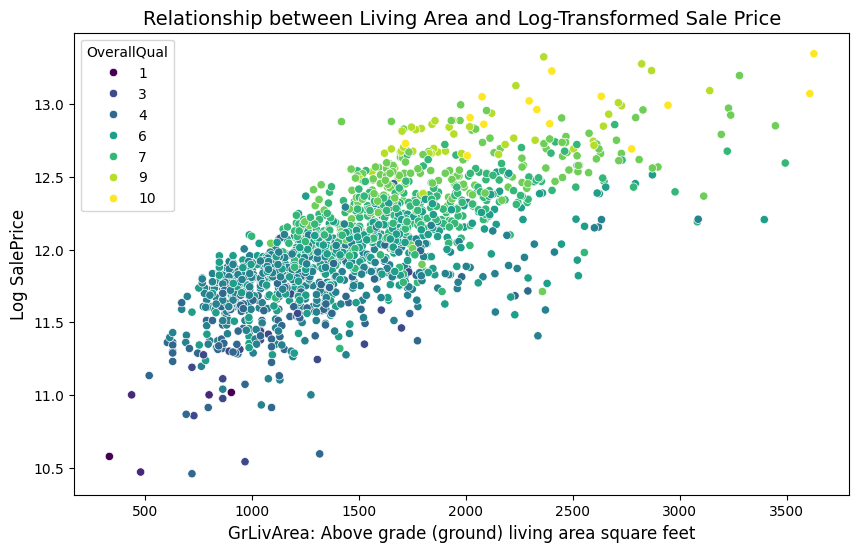

In [22]:



plt.figure(figsize=(10, 6))

sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis')

plt.title('Relationship between Living Area and Log-Transformed Sale Price', fontsize=14)
plt.xlabel('GrLivArea: Above grade (ground) living area square feet', fontsize=12)
plt.ylabel('Log SalePrice', fontsize=12)

plt.show

A scatter plot between GrLivArea and SalePrice, colored by OverallQual, to understand how size and quality drive house prices.

In [18]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

 Feature Engineering
Creating a new feature TotalSF by summing basement and floor areas to capture the total living space in one variable.

In [19]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['ExterQual', 'KitchenQual']

for col in label_cols:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

    le = LabelEncoder()
    all_vals = list(train[col].astype(str)) + list(test[col].astype(str))
    le.fit(all_vals)

    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

 Categorical Encoding
Applying Label Encoding to ordinal features to preserve their rank and One-Hot Encoding to nominal features for model compatibility.

In [20]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

train, test = train.align(test, join='left', axis=1, fill_value=0)